In [15]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [19]:
ds = nc.Dataset('assets/Voxel_Schneckenstein_II_10x10.nc')

print(ds.variables.keys())
print(ds)

dict_keys(['projection', 'x', 'y', 'z', 'Schneckenstein_II_Prediction_0'])
<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.0
    Source_Software: Esri ArcGIS
    esri_pe_string: PROJCS["ETRS_1989_UTM_Zone_33N",GEOGCS["GCS_ETRS_1989",DATUM["D_ETRS_1989",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",15.0],PARAMETER["Scale_Factor",0.9996],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]],VERTCS["Unknown VCS from ArcInfo Workstation",VDATUM["Unknown"],PARAMETER["Vertical_Shift",0.0],PARAMETER["Direction",1.0],UNIT["Meter",1.0]]
    dimensions(sizes): x(24), y(10), z(54)
    variables(dimensions): int32 projection(), float64 x(x), float64 y(y), float64 z(z), float32 Schneckenstein_II_Prediction_0(z, y, x)
    groups: 


Anzahl gültiger Voxel: 8015
Wertebereich Prediction: 1.000 – 24.000


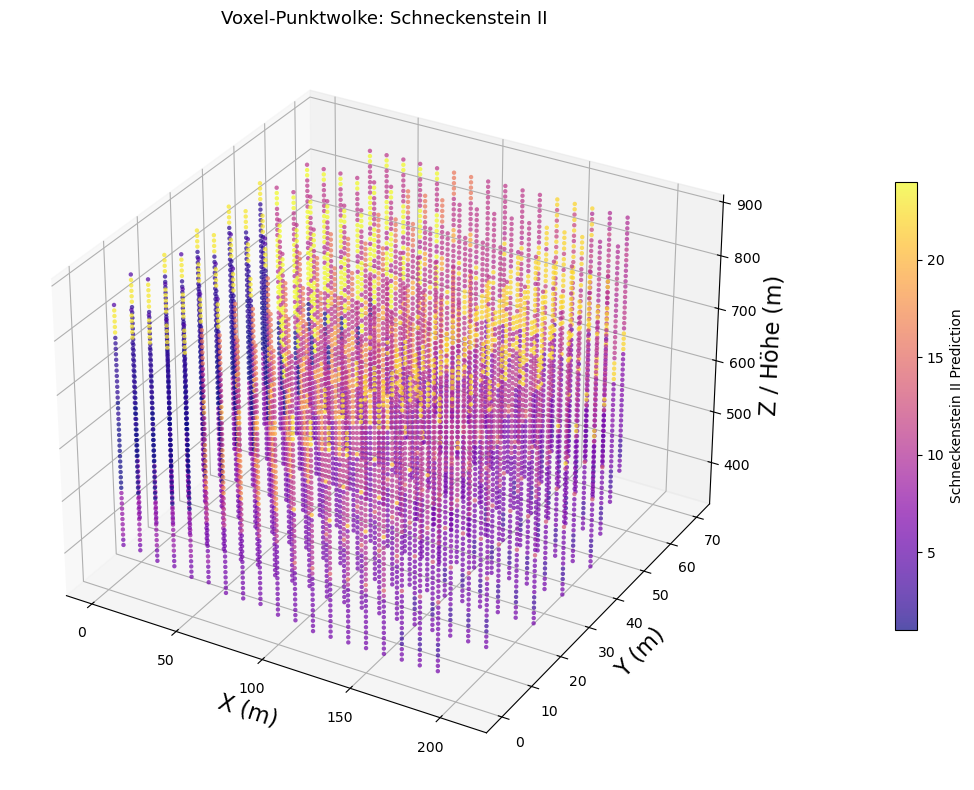

In [18]:
x = ds.variables['x'][:]
y = ds.variables['y'][:]
z = ds.variables['z'][:]
prediction = ds.variables['Schneckenstein_II_Prediction_0'][:]

# Meshgrid erstellen
xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')  # Shape: (24, 10, 54)

# Prediction hat Shape (z, y, x) → transponieren auf (x, y, z)
pred_xyz = prediction.transpose(2, 1, 0)  # Shape: (24, 10, 54)

# Maske: nur Voxel mit gültigem (nicht-maskiertem / nicht-NaN) Wert anzeigen
if np.ma.is_masked(pred_xyz):
    mask = ~pred_xyz.mask
else:
    mask = ~np.isnan(pred_xyz)

# Koordinaten und Werte der gültigen Punkte extrahieren
x_pts = xx[mask]
y_pts = yy[mask]
z_pts = zz[mask]
val_pts = pred_xyz[mask]

# Koordinaten normalisieren für bessere Darstellung
x_norm = x_pts - x_pts.min()
y_norm = y_pts - y_pts.min()

print(f"Anzahl gültiger Voxel: {len(val_pts)}")
print(f"Wertebereich Prediction: {val_pts.min():.3f} – {val_pts.max():.3f}")

# 3D Punktwolke plotten
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x_norm, y_norm, z_pts,
    c=val_pts,
    cmap='plasma',
    s=10,
    alpha=0.7,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Schneckenstein II Prediction', fontsize=10)

ax.set_xlabel('X (m)', fontsize=16)
ax.set_ylabel('Y (m)', fontsize=16)
ax.set_zlabel('Z / Höhe (m)', fontsize=16)
ax.set_title('Voxel-Punktwolke: Schneckenstein II', fontsize=13)

plt.tight_layout()
plt.show()